# Nivel Socioeconómico en Santiago — Análisis de Exposome

**Objetivo:** Construir un indicador de **nivel socioeconómico (NSE) por comuna** en la Región Metropolitana de Santiago, integrando pobreza, ingreso y escolaridad en un índice único.

Cuarto notebook de la serie del **exposome** (junto a salud, calidad del aire y áreas verdes), sobre la **misma base de 52 comunas** para cruzarse por `name`.

**Por qué el NSE:** el nivel socioeconómico es el **determinante social** más transversal del riesgo de demencia y, además, el principal **confusor** que da contexto a todos los demás factores ambientales (las comunas más pobres suelen acumular más contaminación, menos áreas verdes y menos acceso a salud — *injusticia ambiental*). Por eso lo cerramos cruzándolo con los otros tres factores.

**Fuente de datos (abierta, oficial):**
- **Encuesta CASEN 2022** y **estimaciones de pobreza comunal (método SAE)** del Ministerio de Desarrollo Social y Familia, vía el repositorio de datos abiertos [`bastianolea/pobreza_chile`](https://github.com/bastianolea/pobreza_chile) (datos procesados desde las fuentes oficiales).
- Límites comunales desde OSM (`admin_level` 8), recortados a las 52 comunas oficiales de la RM.

**Indicadores generados:**
- `pobreza_pct` — tasa de pobreza por ingresos (%)
- `ingreso` — ingreso total per cápita del hogar (CASEN 2022, $/mes)
- `escolaridad` — años promedio de escolaridad
- `nse_index` — índice socioeconómico compuesto (z-score de ingreso + escolaridad − pobreza; mayor = mejor)
- `poblacion` — población comunal (censo proyectado)

> **Nota:** el `nse_index` estandariza (z-score) cada componente, invierte el signo de la pobreza y promedia. Es un índice relativo dentro de la RM (media ≈ 0), interpretable como posición socioeconómica de la comuna.


In [1]:
import osmnx as ox
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import folium
import os
import warnings
warnings.filterwarnings('ignore')

print(f'osmnx    : {ox.__version__}')
print(f'geopandas: {gpd.__version__}')
print(f'pandas   : {pd.__version__}')

osmnx    : 2.1.0
geopandas: 1.1.3
pandas   : 3.0.3


## 1. Límites comunales (las 52 comunas oficiales de la RM)

Misma extracción y filtro que los notebooks anteriores.

In [2]:
REGION = "Región Metropolitana de Santiago, Chile"

print("Descargando límites comunales desde OSM...")
gdf_communes_raw = ox.features_from_place(
    REGION, tags={"boundary": "administrative", "admin_level": "8"})
gdf_communes = gdf_communes_raw[
    gdf_communes_raw.geometry.geom_type.isin(["Polygon", "MultiPolygon"])
].copy().to_crs(epsg=32719)
gdf_communes = (
    gdf_communes[["name", "geometry"]]
    .dropna(subset=["name"]).dissolve(by="name").reset_index()
)
NON_COMUNA = ("Provincia", "Región", "Dirección", "Departamento", "Distrito")
rm_geom = ox.geocode_to_gdf(REGION).to_crs(epsg=32719).geometry.iloc[0]
gdf_communes = gdf_communes[
    gdf_communes.geometry.centroid.within(rm_geom)
    & ~gdf_communes["name"].str.startswith(NON_COMUNA)
].reset_index(drop=True)
gdf_communes["area_km2"] = gdf_communes.geometry.area / 1e6
print(f"Comunas oficiales de la RM: {len(gdf_communes)}")
gdf_communes.head()

Descargando límites comunales desde OSM...


Comunas oficiales de la RM: 52


,name,geometry,area_km2
0,Alhué,"POLYGON ((287599.305 6232129.935, 287637.866 6...",843.723157
1,Buin,"POLYGON ((324837.929 6258234.358, 324900.841 6...",217.487077
2,Calera de Tango,"POLYGON ((328515.113 6276680.615, 328527.714 6...",73.046707
3,Cerrillos,"POLYGON ((338404.757 6290816.631, 338489.9 629...",16.919765
4,Cerro Navia,"POLYGON ((334318.581 6301418.812, 334341.627 6...",11.140992


## 2. Indicadores socioeconómicos por comuna (CASEN 2022 + pobreza SAE)

Descargamos pobreza comunal (con población) e ingreso/escolaridad de CASEN 2022 desde el repositorio abierto, los unimos por código comunal (CUT) y construimos el índice NSE. Se cachea en `cache/ses_rm_santiago.csv`.

In [3]:
SES_CACHE = "cache/ses_rm_santiago.csv"
os.makedirs("cache", exist_ok=True)

def _num(s):
    # convierte strings con coma decimal (y notación científica) a float
    return pd.to_numeric(s.astype(str).str.replace(",", ".", regex=False), errors="coerce")

if os.path.exists(SES_CACHE):
    ses = pd.read_csv(SES_CACHE)
    print(f"NSE cargado desde cache: {len(ses)} comunas")
else:
    base = "https://raw.githubusercontent.com/bastianolea/pobreza_chile/main/"

    # Pobreza comunal oficial (SAE) + población
    pc = pd.read_csv(base + "pobreza_comunal/datos_procesados/pobreza_comunal.csv", sep=";")
    pc = pc[pc["codigo"].astype(str).str.startswith("13")].copy()      # RM = región 13
    pc["pobreza_pct"] = _num(pc["pobreza_p"]) * 100
    pov = pc[["codigo", "nombre_comuna", "poblacion", "pobreza_pct"]]

    # Ingreso y escolaridad (CASEN 2022), por código comunal
    ig = pd.read_csv(base + "casen/datos_procesados/casen_2022_ingresos.csv", sep=";")
    ig = ig.dropna(subset=["comuna"]).copy()
    ig["codigo"] = ig["comuna"].astype(int)
    ig["ingreso"] = _num(ig["ytotcor"])
    ig["escolaridad"] = _num(ig["esc"])
    ig = ig[ig["codigo"].astype(str).str.startswith("13")][["codigo", "ingreso", "escolaridad"]]

    ses = pov.merge(ig, on="codigo", how="left")
    ses.to_csv(SES_CACHE, index=False)
    print(f"NSE descargado y cacheado: {len(ses)} comunas")

# Índice NSE compuesto (z-score; pobreza con signo invertido)
for col, sign in [("ingreso", 1), ("escolaridad", 1), ("pobreza_pct", -1)]:
    z = (ses[col] - ses[col].mean()) / ses[col].std()
    ses[col + "_z"] = sign * z
ses["nse_index"] = ses[["ingreso_z", "escolaridad_z", "pobreza_pct_z"]].mean(axis=1).round(3)

# Unir a las 52 comunas (por nombre normalizado: "De" vs "de")
ses["key"] = ses["nombre_comuna"].str.lower().str.strip()
gdf_result = gdf_communes.copy()
gdf_result["key"] = gdf_result["name"].str.lower().str.strip()
keep = ["key", "poblacion", "pobreza_pct", "ingreso", "escolaridad", "nse_index"]
gdf_result = gdf_result.merge(ses[keep], on="key", how="left").drop(columns="key")
gdf_result["pobreza_pct"] = gdf_result["pobreza_pct"].round(2)
gdf_result["ingreso"] = gdf_result["ingreso"].round(0)

print(f"Comunas con NSE: {gdf_result['nse_index'].notna().sum()}/{len(gdf_result)}")
print("\nMayor NSE (mejor):")
print(gdf_result.sort_values("nse_index", ascending=False)[
    ["name", "nse_index", "ingreso", "escolaridad", "pobreza_pct"]].head(6).to_string(index=False))
print("\nMenor NSE:")
print(gdf_result.sort_values("nse_index")[
    ["name", "nse_index", "ingreso", "escolaridad", "pobreza_pct"]].head(6).to_string(index=False))

NSE cargado desde cache: 52 comunas
Comunas con NSE: 52/52

Mayor NSE (mejor):
       name  nse_index   ingreso  escolaridad  pobreza_pct
Providencia      2.887 1000000.0    16.256410         4.32
   Vitacura      2.885  950000.0    16.231835         2.44
 Las Condes      2.278  743000.0    15.587839         4.43
      Ñuñoa      2.154  693470.0    15.607636         5.17
   La Reina      1.507  420917.0    14.793025         4.90
 San Miguel      0.964  421694.0    14.093518        12.92

Menor NSE:
       name  nse_index  ingreso  escolaridad  pobreza_pct
  San Pedro     -1.464 198310.0     8.739448        31.93
      Alhué     -1.178 150000.0     9.915305        29.11
     Tiltil     -1.159 193917.0     9.550632        28.91
María Pinto     -1.087 193917.0     9.468438        27.16
 La Pintana     -0.997 156000.0    10.232880        27.00
  Lo Espejo     -0.968 199778.0    10.429599        28.78


## 3. Mapa pub-quality — Índice socioeconómico por comuna

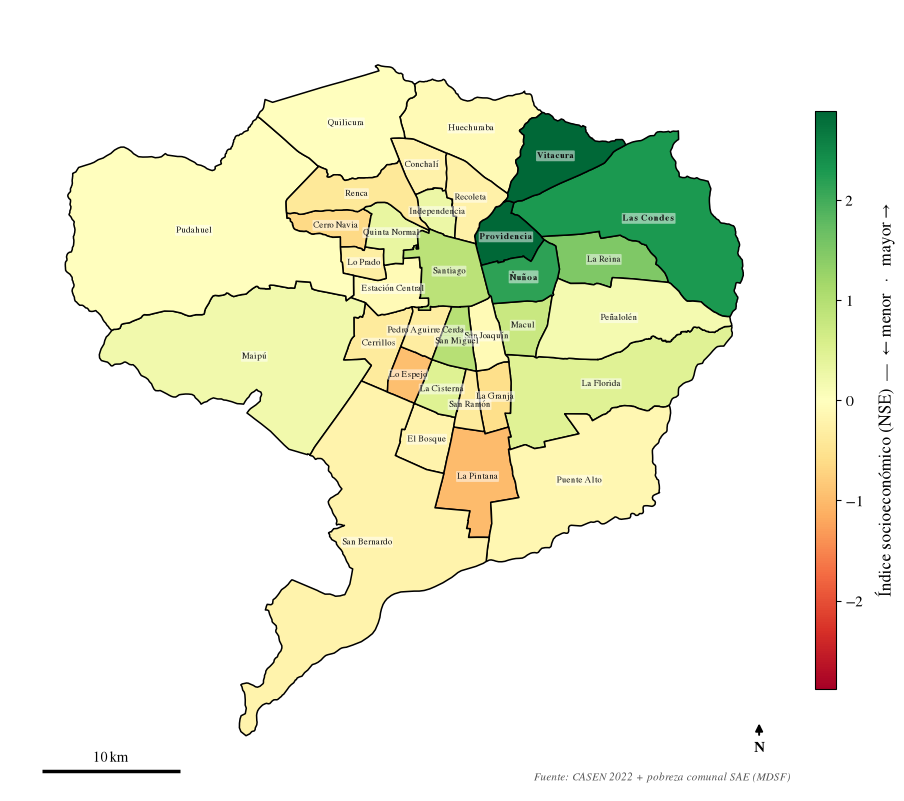

Mapa guardado: socioeconomic_santiago_pub.png


In [4]:
LABEL_ALL = [
    "Providencia", "Santiago", "Ñuñoa", "Las Condes", "Vitacura",
    "Maipú", "Puente Alto", "La Florida", "San Bernardo",
    "Independencia", "Cerro Navia", "San Ramón", "Lo Prado",
    "Recoleta", "Conchalí", "Huechuraba", "Quilicura",
    "Peñalolén", "Macul", "San Miguel", "La Cisterna",
    "El Bosque", "La Pintana", "Pedro Aguirre Cerda",
    "Lo Espejo", "Renca", "Cerrillos",
    "Pudahuel", "Estación Central", "Quinta Normal",
    "San Joaquín", "La Reina", "La Granja",
]

gdf_disp = gdf_result[gdf_result["name"].isin(LABEL_ALL)].to_crs(epsg=32719).copy()
minx, miny, maxx, maxy = gdf_disp.total_bounds
buf = 4_000
X0, X1 = minx - buf, maxx + buf
Y0, Y1 = miny - buf, maxy + buf

vmax = gdf_disp["nse_index"].abs().quantile(0.97)
norm = mcolors.TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax)
cmap = plt.colormaps["RdYlGn"]

plt.rcParams.update({
    "font.family": "STIXGeneral", "mathtext.fontset": "stix",
    "font.size": 11, "axes.linewidth": 0.8,
})

fig, ax = plt.subplots(figsize=(9, 9))
fig.patch.set_alpha(0)
ax.set_facecolor("none")

gdf_disp.plot(column="nse_index", ax=ax, cmap=cmap, norm=norm,
              edgecolor="black", linewidth=1.1,
              missing_kwds={"color": "#dddddd"})
ax.set_xlim(X0, X1)
ax.set_ylim(Y0, Y1)

for _, row in gdf_disp.iterrows():
    c = row.geometry.centroid
    ax.text(c.x, c.y, row["name"], fontsize=6.5, ha="center", va="center", color="#111111",
            fontweight="bold" if abs(row["nse_index"]) > vmax * 0.6 else "normal",
            bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.5))

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.02, aspect=28)
cbar.set_label("Índice socioeconómico (NSE)  —  ← menor   ·   mayor →", fontsize=12, labelpad=8)
cbar.outline.set_linewidth(0.8)
cbar.ax.tick_params(labelsize=11, width=0.8)

dx, dy = X1 - X0, Y1 - Y0
ax.annotate("N", xy=(X1 - dx*0.05, Y0 + dy*0.09), xytext=(X1 - dx*0.05, Y0 + dy*0.05),
            fontsize=11, ha="center", fontweight="bold",
            arrowprops=dict(arrowstyle="-|>", color="black", lw=1.4))
sb_len = 10_000
sb_x, sb_y = X0 + dx*0.04, Y0 + dy*0.025
ax.plot([sb_x, sb_x + sb_len], [sb_y, sb_y], color="black", lw=2.5, solid_capstyle="butt")
ax.text(sb_x + sb_len/2, sb_y + dy*0.008, "10 km", ha="center", va="bottom", fontsize=10)

ax.text(0.99, 0.01, "Fuente: CASEN 2022 + pobreza comunal SAE (MDSF)",
        transform=ax.transAxes, fontsize=8, ha="right", va="bottom",
        color="#555555", fontstyle="italic")
ax.set_axis_off()
plt.tight_layout(pad=0.5)
plt.savefig("socioeconomic_santiago_pub.png", dpi=300, bbox_inches="tight", transparent=True)
plt.show()
print("Mapa guardado: socioeconomic_santiago_pub.png")

## 4. Mapa interactivo con Folium

In [5]:
gdf_wgs = gdf_result.to_crs(epsg=4326).copy()
for c in ["nse_index", "pobreza_pct", "escolaridad"]:
    gdf_wgs[c] = gdf_wgs[c].round(2)
gdf_wgs["ingreso"] = gdf_wgs["ingreso"].round(0)

m = folium.Map(location=[-33.52, -70.66], zoom_start=10, tiles="CartoDB positron")

folium.Choropleth(
    geo_data=gdf_wgs.__geo_interface__,
    data=gdf_wgs,
    columns=["name", "nse_index"],
    key_on="feature.properties.name",
    fill_color="RdYlGn",
    fill_opacity=0.75, line_opacity=0.3,
    legend_name="Índice socioeconómico (NSE)",
    nan_fill_color="lightgrey",
).add_to(m)

folium.GeoJson(
    gdf_wgs.__geo_interface__,
    style_function=lambda x: {"fillColor": "transparent", "color": "transparent"},
    tooltip=folium.GeoJsonTooltip(
        fields=["name", "nse_index", "ingreso", "escolaridad", "pobreza_pct"],
        aliases=["Comuna", "Índice NSE", "Ingreso ($/mes)", "Escolaridad (años)", "Pobreza (%)"],
        localize=True,
    ),
).add_to(m)

folium.LayerControl().add_to(m)
m.save("socioeconomic_santiago.html")
print("Mapa interactivo guardado: socioeconomic_santiago.html")
m

Mapa interactivo guardado: socioeconomic_santiago.html


## 5. Ranking comunal y brecha socioeconómica

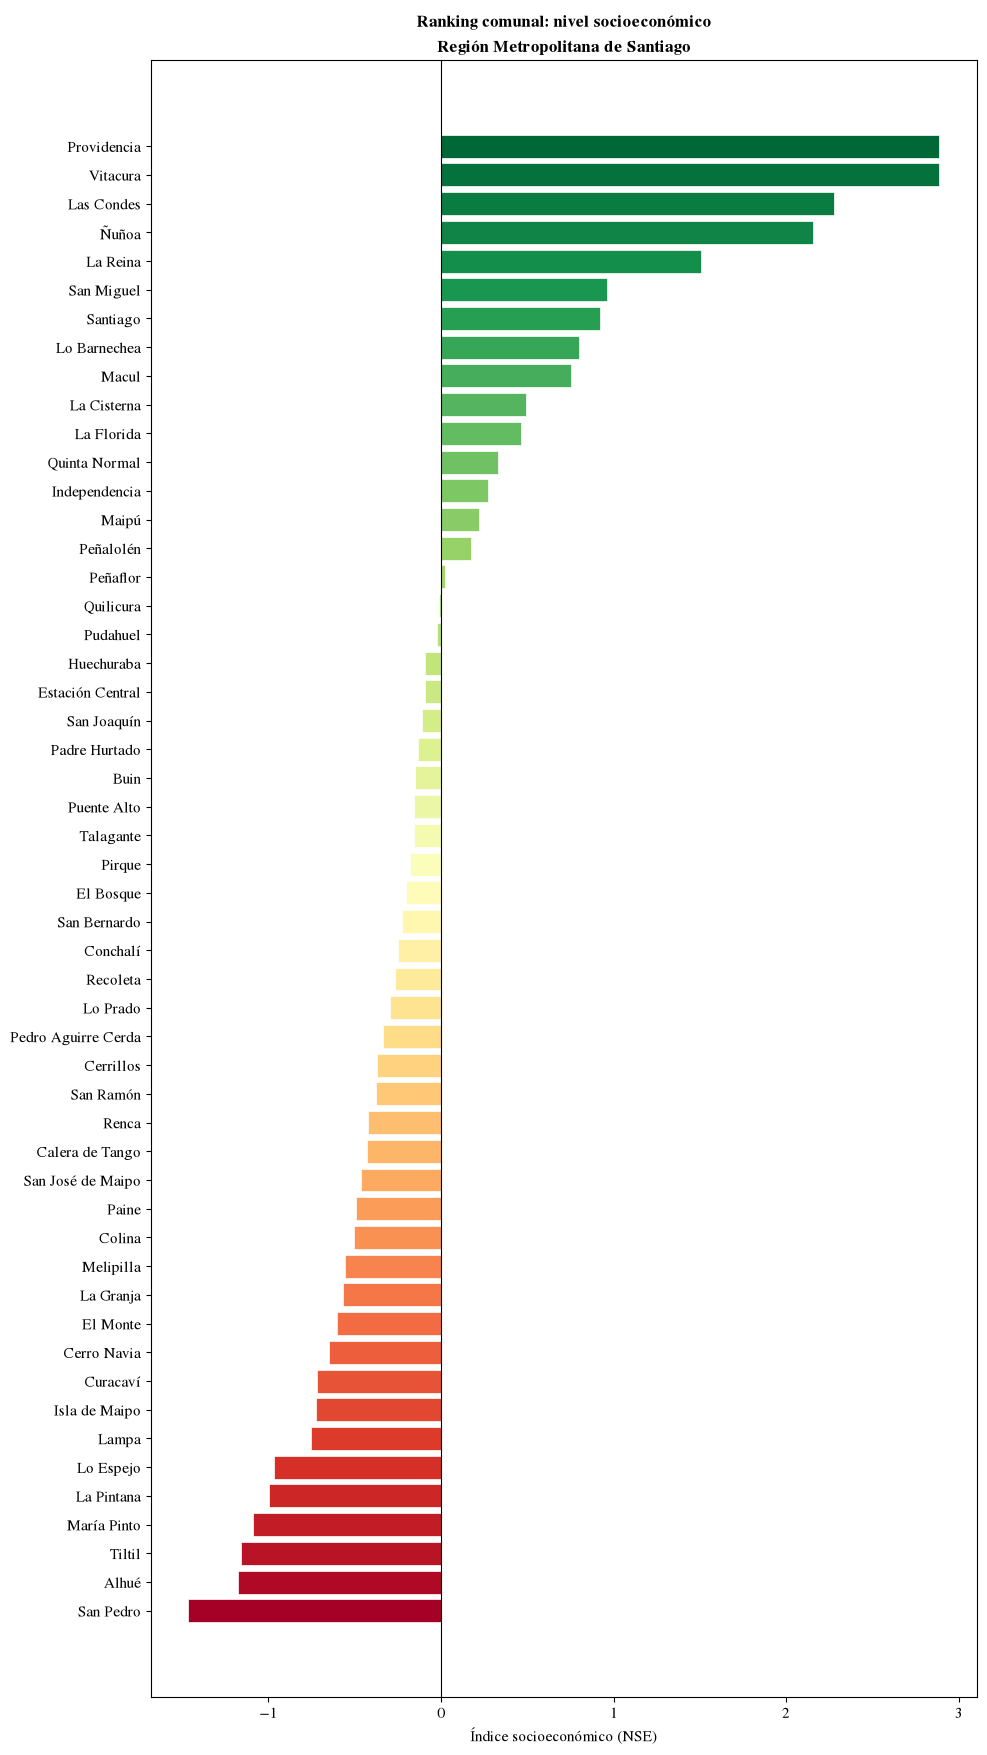


--- Brecha socioeconómica ---
  Mayor NSE: Providencia → ingreso $1,000,000/mes · pobreza 4.3%
  Menor NSE: San Pedro → ingreso $198,310/mes · pobreza 31.9%
  Razón de ingreso (máx/mín): 5.0x


In [6]:
df_ranked = (
    gdf_result[["name", "nse_index", "ingreso", "pobreza_pct"]]
    .dropna(subset=["nse_index"])
    .sort_values("nse_index", ascending=False)
    .reset_index(drop=True)
)
df_ranked.index += 1

fig, ax = plt.subplots(figsize=(10, max(6, len(df_ranked) * 0.34)))
colors = plt.cm.RdYlGn(np.linspace(1, 0, len(df_ranked)))   # verde = mayor NSE (mejor)
ax.barh(df_ranked["name"], df_ranked["nse_index"], color=colors,
        edgecolor="white", linewidth=0.5)
ax.set_xlabel("Índice socioeconómico (NSE)", fontsize=11)
ax.set_title("Ranking comunal: nivel socioeconómico\nRegión Metropolitana de Santiago",
             fontsize=12, fontweight="bold")
ax.invert_yaxis()
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("socioeconomic_ranking_santiago.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n--- Brecha socioeconómica ---")
top, bot = df_ranked.iloc[0], df_ranked.iloc[-1]
print(f"  Mayor NSE: {top['name']} → ingreso ${top['ingreso']:,.0f}/mes · pobreza {top['pobreza_pct']:.1f}%")
print(f"  Menor NSE: {bot['name']} → ingreso ${bot['ingreso']:,.0f}/mes · pobreza {bot['pobreza_pct']:.1f}%")
print(f"  Razón de ingreso (máx/mín): {top['ingreso']/bot['ingreso']:.1f}x")

## 6. Exportar indicadores

In [7]:
df_export = gdf_result.drop(columns="geometry").copy()
df_export["area_km2"] = df_export["area_km2"].round(2)
df_export.to_csv("socioeconomic_exposome_rm_santiago.csv", index=False)
gdf_wgs.to_file("socioeconomic_exposome_rm_santiago.geojson", driver="GeoJSON")

print("Archivos exportados:")
print("  socioeconomic_exposome_rm_santiago.csv     — indicadores por comuna")
print("  socioeconomic_exposome_rm_santiago.geojson — capa geoespacial")
print(f"\nDataset final: {len(df_export)} comunas × {len(df_export.columns)} variables")
print("Columnas:", list(df_export.columns))
df_export.sort_values("nse_index", ascending=False).head()

Archivos exportados:
  socioeconomic_exposome_rm_santiago.csv     — indicadores por comuna
  socioeconomic_exposome_rm_santiago.geojson — capa geoespacial

Dataset final: 52 comunas × 7 variables
Columnas: ['name', 'area_km2', 'poblacion', 'pobreza_pct', 'ingreso', 'escolaridad', 'nse_index']


,name,area_km2,poblacion,pobreza_pct,ingreso,escolaridad,nse_index
34,Providencia,14.43,162013,4.32,1000000.0,16.256410,2.887
50,Vitacura,28.29,97546,2.44,950000.0,16.231835,2.885
20,Las Condes,98.90,339547,4.43,743000.0,15.587839,2.278
51,Ñuñoa,16.91,261138,5.17,693470.0,15.607636,2.154
18,La Reina,23.64,99946,4.90,420917.0,14.793025,1.507


## 7. Integración del exposome — NSE vs. ambiente

El paso que más le interesa a BrainLat: ¿se **acumulan las desventajas**? Cruzamos el NSE con los otros tres factores ya construidos y medimos la correlación de Spearman. El resultado es **matizado pero estadísticamente claro**: la desigualdad social es **significativa** en **áreas verdes** (ρ≈+0.44, p<0.001) y **acceso a salud** (ρ≈+0.59, p<0.001) — las comunas de mayor NSE concentran ambas —, mientras que la correlación con **PM2.5** y **NO₂ no es significativa** (ρ≈+0.05–0.09, p>0.5): el aire está más determinado por la **topografía de la cuenca** (inversión térmica, altura cordillerana) que por el NSE. En Santiago la inequidad ambiental opera sobre todo vía *acceso a áreas verdes y servicios*, no por la calidad del aire.

Correlación de Spearman del NSE con los demás factores del exposome:
  factor               ρ      p-value   signif.
  NSE vs PM2.5           +0.09     0.5358    ns
  NSE vs NO₂             +0.05     0.7380    ns
  NSE vs Áreas verdes (%)  +0.44     0.0010    ***
  NSE vs Densidad salud  +0.59     0.0000    ***
  (n = 52; significancia: *** p<0.001 · ** p<0.01 · * p<0.05 · ns = no significativo)


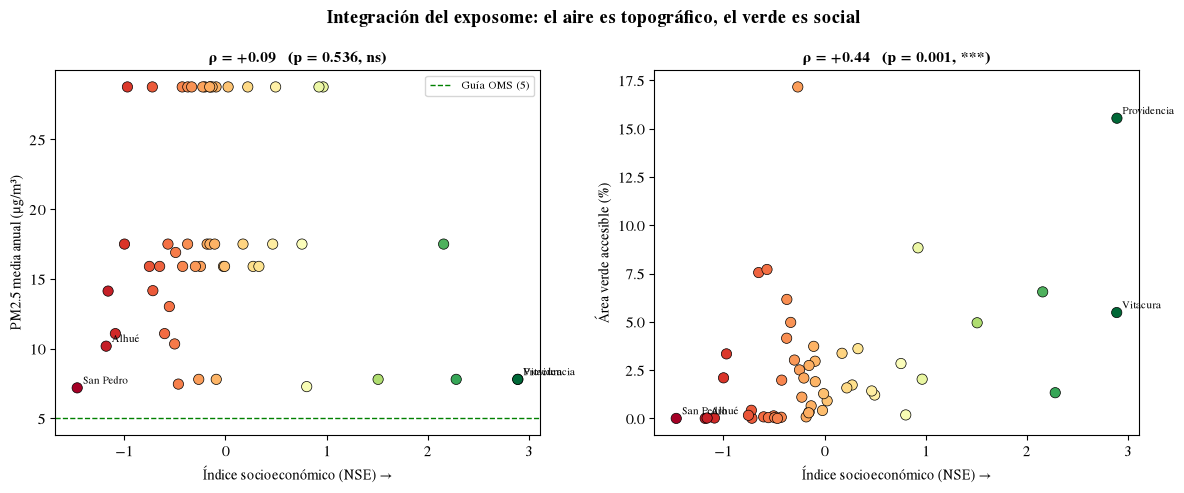


Gráfico guardado: nse_vs_exposome_santiago.png


In [8]:
expo = gdf_result[["name", "nse_index", "ingreso", "pobreza_pct"]].copy()
others = {
    "air_quality_exposome_rm_santiago.csv": ["pm25_mean", "no2_mean"],
    "green_exposome_rm_santiago.csv": ["green_pct"],
    "healthcare_exposome_rm_santiago.csv": ["density_per_km2"],
}
for f, cols in others.items():
    if os.path.exists(f):
        expo = expo.merge(pd.read_csv(f)[["name"] + cols], on="name", how="left")


from scipy.stats import spearmanr


def spearman(x, y):
    # ρ de Spearman + p-value (dos colas), sobre el n efectivo tras descartar NaN
    d = pd.concat([x, y], axis=1).dropna()
    rho, p = spearmanr(d.iloc[:, 0], d.iloc[:, 1])
    return float(rho), float(p), len(d)


def sig_mark(p):
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"


labels = {"pm25_mean": "PM2.5", "no2_mean": "NO₂",
          "green_pct": "Áreas verdes (%)", "density_per_km2": "Densidad salud"}
print("Correlación de Spearman del NSE con los demás factores del exposome:")
print(f"  {'factor':16s}     ρ      p-value   signif.")
for c in ["pm25_mean", "no2_mean", "green_pct", "density_per_km2"]:
    if c in expo:
        rho, p, n = spearman(expo["nse_index"], expo[c])
        print(f"  NSE vs {labels[c]:14s}  {rho:+.2f}   {p:8.4f}    {sig_mark(p)}")
print(f"  (n = {n}; significancia: *** p<0.001 · ** p<0.01 · * p<0.05 · ns = no significativo)")

# Panel doble: NSE vs PM2.5 (topográfico) y NSE vs áreas verdes (social)
def _scatter(ax, ycol, ylabel, hline=None, hlabel=None):
    sub = expo.dropna(subset=["nse_index", ycol])
    ax.scatter(sub["nse_index"], sub[ycol], c=sub["nse_index"],
               cmap="RdYlGn", edgecolor="black", linewidth=0.5, s=55, zorder=3)
    for _, r in pd.concat([sub.nlargest(2, "nse_index"),
                           sub.nsmallest(2, "nse_index")]).drop_duplicates("name").iterrows():
        ax.annotate(r["name"], (r["nse_index"], r[ycol]),
                    fontsize=7.5, xytext=(4, 3), textcoords="offset points")
    if hline is not None:
        ax.axhline(hline, color="green", ls="--", lw=1, label=hlabel)
        ax.legend(fontsize=8)
    rho, p, n = spearman(sub["nse_index"], sub[ycol])
    ax.set_xlabel("Índice socioeconómico (NSE) →", fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(f"ρ = {rho:+.2f}   (p = {p:.3f}, {sig_mark(p)})", fontsize=11, fontweight="bold")

panels = [c for c in ["pm25_mean", "green_pct"] if c in expo]
if panels:
    fig, axes = plt.subplots(1, len(panels), figsize=(6 * len(panels), 5))
    axes = np.atleast_1d(axes)
    if "pm25_mean" in expo:
        _scatter(axes[0], "pm25_mean", "PM2.5 media anual (µg/m³)",
                 hline=5, hlabel="Guía OMS (5)")
    if "green_pct" in expo:
        _scatter(axes[-1], "green_pct", "Área verde accesible (%)")
    fig.suptitle("Integración del exposome: el aire es topográfico, el verde es social",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("nse_vs_exposome_santiago.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("\nGráfico guardado: nse_vs_exposome_santiago.png")